In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [72]:
df = pd.read_csv("Housing.csv")

In [73]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [75]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [76]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(0)

Visualize the distribution of Prices

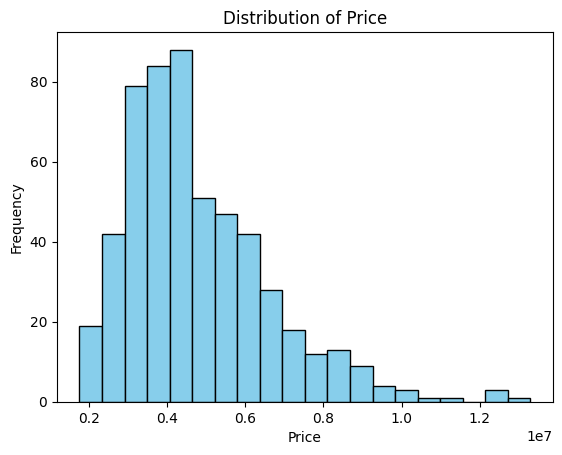

In [78]:
plt.hist(df["price"], bins = 20, color = "skyblue", edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [79]:
df["furnishingstatus"].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [80]:
df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

In [81]:
df.sort_values(by="area", ascending=False)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
403,3500000,12944,3,1,1,yes,no,no,no,no,0,no,unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2240000,1950,3,1,1,no,no,no,yes,no,0,no,unfurnished
271,4340000,1905,5,1,2,no,no,yes,no,no,0,no,semi-furnished
527,2275000,1836,2,1,1,no,no,yes,no,no,0,no,semi-furnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished


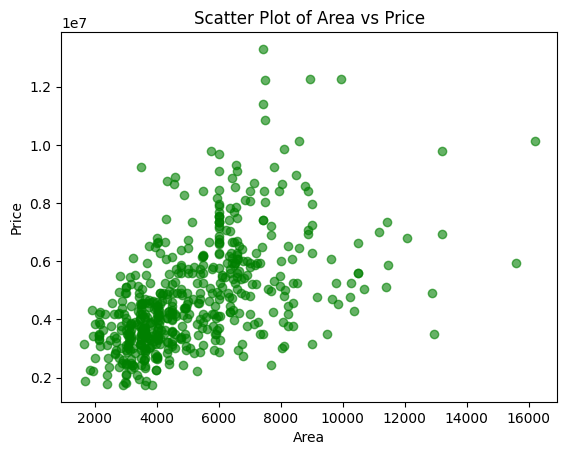

In [82]:
plt.scatter(df["area"],df["price"], color="green", alpha = 0.6)
plt.title("Scatter Plot of Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

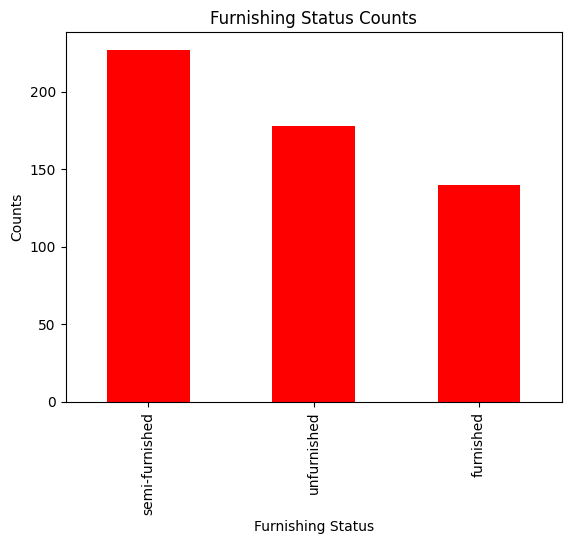

In [83]:
df["furnishingstatus"].value_counts().plot(kind="bar", color="red")
plt.title("Furnishing Status Counts")
plt.xlabel("Furnishing Status")
plt.ylabel("Counts")
plt.show()

In [84]:
df["mainroad"].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [85]:
df["hotwaterheating"].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [86]:
df["airconditioning"].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

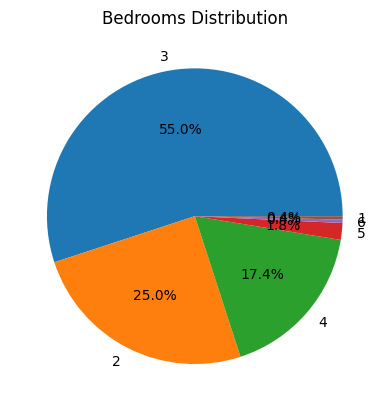

In [87]:
df["bedrooms"].value_counts().plot(kind="pie", autopct = "%1.1f%%")
plt.title("Bedrooms Distribution")
plt.ylabel("")
plt.show()

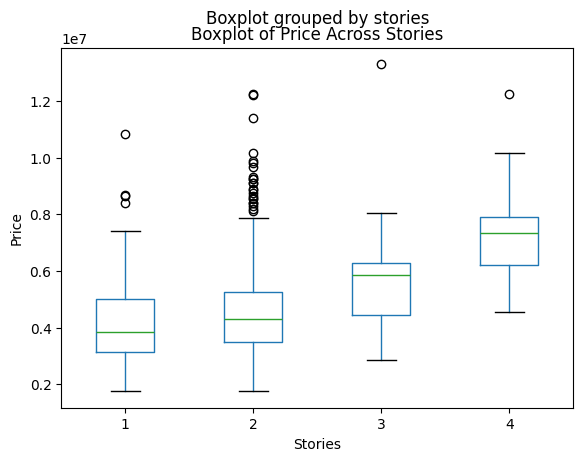

In [88]:
df.boxplot(column = "price", by="stories", grid=False)
plt.title("Boxplot of Price Across Stories")
plt.xlabel("Stories")
plt.ylabel("Price")
plt.show()

In [89]:
df.groupby("guestroom")["price"].mean()

guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

In [90]:
df.groupby("basement")["area"].max()

basement
no     16200
yes    13200
Name: area, dtype: int64

In [91]:
df.groupby("airconditioning")["price"].median()

airconditioning
no     3885000.0
yes    5757500.0
Name: price, dtype: float64

In [92]:
df.groupby("mainroad")["price"].min()

mainroad
no     1750000
yes    1750000
Name: price, dtype: int64

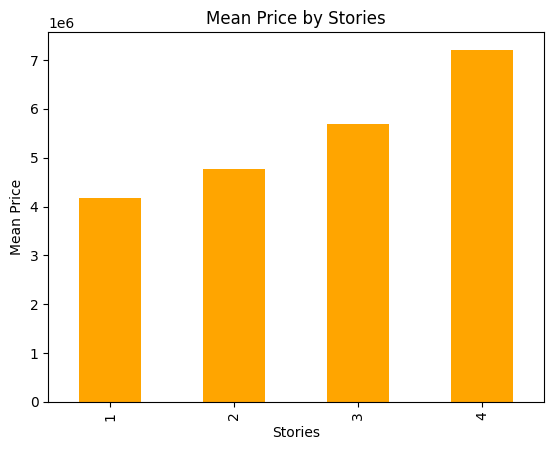

In [93]:
df.groupby("stories")["price"].mean().plot(kind="bar",color="orange")
plt.title("Mean Price by Stories")
plt.xlabel("Stories")
plt.ylabel("Mean Price")
plt.show()

Selecting columns for Model

In [94]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [95]:
from sklearn import preprocessing
labelencoder = preprocessing.LabelEncoder()
df["mainroad"] = labelencoder.fit_transform(df["mainroad"])
df["furnishingstatus"] = labelencoder.fit_transform(df["furnishingstatus"])

In [96]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,yes,2,yes,0
1,12250000,8960,4,4,4,1,no,no,no,yes,3,no,0
2,12250000,9960,3,2,2,1,no,yes,no,no,2,yes,1
3,12215000,7500,4,2,2,1,no,yes,no,yes,3,yes,0
4,11410000,7420,4,1,2,1,yes,yes,no,yes,2,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,no,yes,no,no,2,no,2
541,1767150,2400,3,1,1,0,no,no,no,no,0,no,1
542,1750000,3620,2,1,1,1,no,no,no,no,0,no,2
543,1750000,2910,3,1,1,0,no,no,no,no,0,no,0


In [97]:
y = df["price"]
X = df[["area", "bedrooms", "bathrooms", "mainroad", "furnishingstatus"]]

In [98]:
X

,area,bedrooms,bathrooms,mainroad,furnishingstatus
0,7420,4,2,1,0
1,8960,4,4,1,0
2,9960,3,2,1,1
3,7500,4,2,1,0
4,7420,4,1,1,0
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,0,1
542,3620,2,1,1,2
543,2910,3,1,0,0


In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

SCALING DATA

In [100]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def modelresults(predictions):
    print("Mean absolute error on model is {}".format(mean_absolute_error(y_test, predictions)))
    print("Root mean squared error on model is {}".format(np.sqrt(mean_squared_error(y_test,predictions))))



In [102]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(scaled_X_train, y_train)
predslr = lr.predict(scaled_X_test)
modelresults(predslr)

Mean absolute error on model is 994099.2575739393
Root mean squared error on model is 1337827.8503302601


Creating a support vector model

In [103]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
svrmodel = SVR()

In [104]:
param_gridsvr = {"C" : [0.001, 0.01, 0.1, 0.5], 
                 "kernel" : ["linear", "rbf","poly"],
                 "gamma"  : ["scale","auto"],
                 "degree" : [2,3,4,5]}

In [105]:
gridsvr = GridSearchCV(svrmodel, param_gridsvr)

In [106]:
gridsvr.fit(scaled_X_train, y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5], 'degree': [2, 3, 4, 5],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']})

In [107]:
print("Best parameters for model is {}".format(gridsvr.best_params_))

Best parameters for model is {'C': 0.5, 'degree': 5, 'gamma': 'scale', 'kernel': 'poly'}


In [108]:
predgridsvr = gridsvr.predict(scaled_X_test)

In [109]:
modelresults(predgridsvr)

Mean absolute error on model is 1390883.2316062876
Root mean squared error on model is 1943908.6207673212


In [110]:
from xgboost import XGBRegressor

In [111]:
from xgboost import XGBRegressor
xgb = XGBRegressor()

In [112]:
param_grid = {
    "n_estimators" : [50,100,500,1000,2000],
    "learning_rate" :[0.01,0.1,0.2,0.5],
    "max_depth" : [3,5,7,9]
}

In [113]:
grid_search = GridSearchCV(xgb, param_grid, cv = 3)
grid_search.fit(scaled_X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.5],
                         'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 500, 1000, 2000]})

In [114]:
grid_search.best_params_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}

In [115]:
xgbpred = grid_search.predict(scaled_X_test)

In [116]:
modelresults(xgbpred)

Mean absolute error on model is 1067195.625
Root mean squared error on model is 1515299.9624048038
